# WanderStay Listings — Data Cleaning & Exploratory Analysis

This notebook loads the raw WanderStay listings dataset, inspects it, fixes data types, removes invalid records, explores the variables visually, and finally **corrects the categorical variables and handles missing values** so the DataFrame is clean and ready for the next stage of work.

## 1. Setup & Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: Set a style for your plots
sns.set_theme(style="whitegrid")

## 2. Load the Dataset

Read the CSV and preview the first few rows to confirm it loaded correctly.

In [2]:
# Load the dataset
df = pd.read_csv('wanderstay_listings.csv')

# Display the first few rows to verify it loaded correctly
df.head()

,listing_id,host_id,host_since,host_is_superhost,host_listings_count,city,neighborhood,property_type,room_type,accommodates,...,amenities,distance_to_center_km,minimum_nights,number_of_reviews,review_scores_rating,instant_bookable,availability_365,estimated_monthly_revenue,internal_quality_score,price
0,WS100859,1741,2016-06-26,t,1,Delhi,Connaught Place,Penthouse,Entire home,6,...,"{Wifi,AC,Pool,Washing Machine,TV,Heater,Pet Fr...",0.19,1,23,82.5,f,197,57789.0,59.3,"₹4,647"
1,WS103542,2132,2024-03-27,t,4,Pune,Hinjewadi,Cottage,Shared room,7,...,"{Wifi,AC,Kitchen,Parking,TV}",3.52,1,5,90.0,t,141,47279.0,14.9,"₹2,799"
2,WS103703,4530,2015-07-23,f,3,Pune,Kothrud,Apartment,Private room,5,...,"{Wifi,AC,Washing Machine,TV,Heater}",10.40,7,13,91.5,t,48,20813.0,16.2,"₹1,138"
3,WS101270,3058,2018-06-07,t,2,Bangalore,HSR Layout,Studio,Shared room,2,...,"{Wifi,AC,Kitchen,TV,Heater,Workspace}",4.86,3,16,83.0,t,150,14777.0,93.5,₹947
4,WS103190,7081,2020-02-26,f,3,Jaipur,Malviya Nagar,Villa,Entire home,2,...,"{Wifi,AC,Kitchen,Parking,Pool,TV}",2.99,7,16,74.2,t,111,62754.0,31.3,"₹3,038"


## 3. Initial Inspection

Check the structure (column names, data types, non-null counts) and the number of missing values per column.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4035 entries, 0 to 4034
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   listing_id                 4035 non-null   object 
 1   host_id                    4035 non-null   int64  
 2   host_since                 3955 non-null   object 
 3   host_is_superhost          4010 non-null   object 
 4   host_listings_count        4035 non-null   int64  
 5   city                       4035 non-null   object 
 6   neighborhood               3975 non-null   object 
 7   property_type              4035 non-null   object 
 8   room_type                  4035 non-null   object 
 9   accommodates               4035 non-null   int64  
 10  bedrooms                   3831 non-null   float64
 11  bathrooms                  3914 non-null   float64
 12  beds                       4035 non-null   int64  
 13  amenities                  4035 non-null   objec

In [4]:
# Display the count of null values for each column
df.isnull().sum()

listing_id                     0
host_id                        0
host_since                    80
host_is_superhost             25
host_listings_count            0
city                           0
neighborhood                  60
property_type                  0
room_type                      0
accommodates                   0
bedrooms                     204
bathrooms                    121
beds                           0
amenities                      0
distance_to_center_km          0
minimum_nights                 0
number_of_reviews              0
review_scores_rating         146
instant_bookable              24
availability_365               0
estimated_monthly_revenue      0
internal_quality_score         0
price                          0
dtype: int64

## 4. Fix Data Types

`host_since` is read in as text. Convert it to a proper `datetime` type so it can be used for date-based calculations later (e.g. median date imputation).

In [5]:
# Convert host_since to datetime objects
df['host_since'] = pd.to_datetime(df['host_since'])

# Verify the conversion
print(df['host_since'].dtype)

datetime64[ns]


## 5. Summary Statistics & Removing Invalid Records

Review the numeric summary, then drop physically impossible records (negative bedrooms, distance, or revenue) and re-check the statistics.

In [6]:
df.describe()

,host_id,host_since,host_listings_count,accommodates,bedrooms,bathrooms,beds,distance_to_center_km,minimum_nights,number_of_reviews,review_scores_rating,availability_365,estimated_monthly_revenue,internal_quality_score
count,4035.000000,3955,4035.000000,4035.000000,3831.000000,3914.000000,4035.000000,4035.000000,4035.000000,4035.000000,3889.000000,4035.000000,4035.000000,4035.000000
mean,5480.653284,2020-01-11 01:46:18.963337728,2.981908,4.736803,1.662490,1.499617,3.810657,4.952659,4.732094,19.933581,89.593572,179.135068,44251.930607,49.558959
min,1001.000000,2015-01-01 00:00:00,1.000000,0.000000,-1.000000,1.000000,1.000000,-3.000000,1.000000,0.000000,68.200000,0.000000,-778.000000,0.000000
25%,3344.000000,2017-07-06 12:00:00,2.000000,3.000000,1.000000,1.000000,2.000000,1.420000,1.000000,9.000000,85.200000,87.000000,17503.000000,25.200000
50%,5467.000000,2019-12-07 00:00:00,3.000000,4.000000,1.000000,1.500000,3.000000,3.480000,2.000000,19.000000,89.800000,179.000000,35435.000000,49.300000
75%,7708.000000,2022-07-03 12:00:00,4.000000,6.000000,2.000000,1.500000,5.000000,6.965000,5.000000,29.000000,94.400000,269.000000,59261.500000,74.000000
max,9996.000000,2027-03-15 00:00:00,11.000000,16.000000,8.000000,6.000000,16.000000,35.000000,1000.000000,57.000000,100.000000,365.000000,545451.000000,99.900000
std,2572.279582,NaN,1.416462,2.520244,0.950278,0.672703,2.120639,4.842621,44.413250,12.303066,6.475568,105.308856,38077.127927,28.580645


In [7]:
# Filter out the invalid data points
df = df[
    (df['bedrooms'] >= 0) & 
    (df['distance_to_center_km'] >= 0) & 
    (df['estimated_monthly_revenue'] >= 0)
]

# Verify the changes
df.describe()

,host_id,host_since,host_listings_count,accommodates,bedrooms,bathrooms,beds,distance_to_center_km,minimum_nights,number_of_reviews,review_scores_rating,availability_365,estimated_monthly_revenue,internal_quality_score
count,3817.000000,3744,3817.000000,3817.000000,3817.000000,3705.000000,3817.000000,3817.000000,3817.000000,3817.000000,3680.000000,3817.000000,3817.000000,3817.000000
mean,5485.859576,2020-01-08 15:26:09.230769408,2.971182,4.741944,1.666492,1.501484,3.810322,4.971234,4.575845,19.899921,89.587174,179.187844,44213.533403,49.609746
min,1001.000000,2015-01-01 00:00:00,1.000000,0.000000,1.000000,1.000000,1.000000,0.100000,1.000000,0.000000,68.200000,0.000000,84.000000,0.000000
25%,3335.000000,2017-07-10 00:00:00,2.000000,3.000000,1.000000,1.000000,2.000000,1.430000,1.000000,9.000000,85.200000,88.000000,17547.000000,25.200000
50%,5478.000000,2019-12-04 12:00:00,3.000000,4.000000,1.000000,1.500000,3.000000,3.500000,2.000000,19.000000,89.800000,179.000000,35365.000000,49.700000
75%,7735.000000,2022-06-30 00:00:00,4.000000,6.000000,2.000000,1.500000,5.000000,6.990000,5.000000,29.000000,94.425000,269.000000,59214.000000,74.200000
max,9996.000000,2027-03-15 00:00:00,11.000000,16.000000,8.000000,6.000000,16.000000,35.000000,1000.000000,57.000000,100.000000,365.000000,545451.000000,99.900000
std,2577.016780,NaN,1.415217,2.523932,0.947307,0.670809,2.121485,4.826128,42.722062,12.290911,6.481337,105.257155,37934.880643,28.650270


Quick look at just the **mean** and **standard deviation** for each numeric column:

In [8]:
# Extract and display only the mean and standard deviation
stats = df.describe().loc[['mean', 'std']]
print(stats)

          host_id                     host_since  host_listings_count  \
mean  5485.859576  2020-01-08 15:26:09.230769408             2.971182   
std   2577.016780                            NaN             1.415217   

      accommodates  bedrooms  bathrooms      beds  distance_to_center_km  \
mean      4.741944  1.666492   1.501484  3.810322               4.971234   
std       2.523932  0.947307   0.670809  2.121485               4.826128   

      minimum_nights  number_of_reviews  review_scores_rating  \
mean        4.575845          19.899921             89.587174   
std        42.722062          12.290911              6.481337   

      availability_365  estimated_monthly_revenue  internal_quality_score  
mean        179.187844               44213.533403               49.609746  
std         105.257155               37934.880643               28.650270  


## 6. Identifying & Summarising Categorical Variables

List the text (object) columns, then summarise the genuinely categorical ones with both **counts** and **percentages** for each category.

In [9]:
# Select only columns with 'object' data type
object_cols = df.select_dtypes(include=['object']).columns.tolist()

# Display the list of object columns
print("Columns with object data type:", object_cols)

# If you want to see the first few rows of just these columns:
df[object_cols].head()

Columns with object data type: ['listing_id', 'host_is_superhost', 'city', 'neighborhood', 'property_type', 'room_type', 'amenities', 'instant_bookable', 'price']


,listing_id,host_is_superhost,city,neighborhood,property_type,room_type,amenities,instant_bookable,price
0,WS100859,t,Delhi,Connaught Place,Penthouse,Entire home,"{Wifi,AC,Pool,Washing Machine,TV,Heater,Pet Fr...",f,"₹4,647"
1,WS103542,t,Pune,Hinjewadi,Cottage,Shared room,"{Wifi,AC,Kitchen,Parking,TV}",t,"₹2,799"
2,WS103703,f,Pune,Kothrud,Apartment,Private room,"{Wifi,AC,Washing Machine,TV,Heater}",t,"₹1,138"
3,WS101270,t,Bangalore,HSR Layout,Studio,Shared room,"{Wifi,AC,Kitchen,TV,Heater,Workspace}",t,₹947
4,WS103190,f,Jaipur,Malviya Nagar,Villa,Entire home,"{Wifi,AC,Kitchen,Parking,Pool,TV}",t,"₹3,038"


In [10]:
# List of columns to analyze
cat_cols_to_analyze = ['host_is_superhost', 'city', 'neighborhood', 'property_type', 'room_type', 'instant_bookable']

for col in cat_cols_to_analyze:
    # Get counts
    counts = df[col].value_counts()
    # Get percentages
    percentages = df[col].value_counts(normalize=True) * 100
    
    # Combine into a single DataFrame
    summary = pd.DataFrame({'Count': counts, 'Percentage': percentages})
    
    # Format the percentage for better readability
    summary['Percentage'] = summary['Percentage'].map('{:.2f}%'.format)
    
    print(f"\n--- {col} Summary ---")
    print(summary)


--- host_is_superhost Summary ---
                   Count Percentage
host_is_superhost                  
f                   2662     70.20%
t                   1074     28.32%
True                  21      0.55%
TRUE                  18      0.47%
False                 17      0.45%

--- city Summary ---
            Count Percentage
city                        
Mumbai        819     21.46%
Delhi         736     19.28%
Bangalore     713     18.68%
Goa           489     12.81%
Pune          423     11.08%
Jaipur        328      8.59%
Mumbai         72      1.89%
Delhi          72      1.89%
 Bangalore     54      1.41%
PUNE           41      1.07%
GOA            38      1.00%
jaipur         32      0.84%

--- neighborhood Summary ---
                 Count Percentage
neighborhood                     
Powai              161      4.28%
Bandra             160      4.26%
Worli              148      3.94%
Colaba             147      3.91%
Connaught Place    143      3.80%
MG Road          

## 7. Distributions of Continuous Variables

Kernel density estimates (PDFs) for the continuous numeric variables to understand their shape and spread.

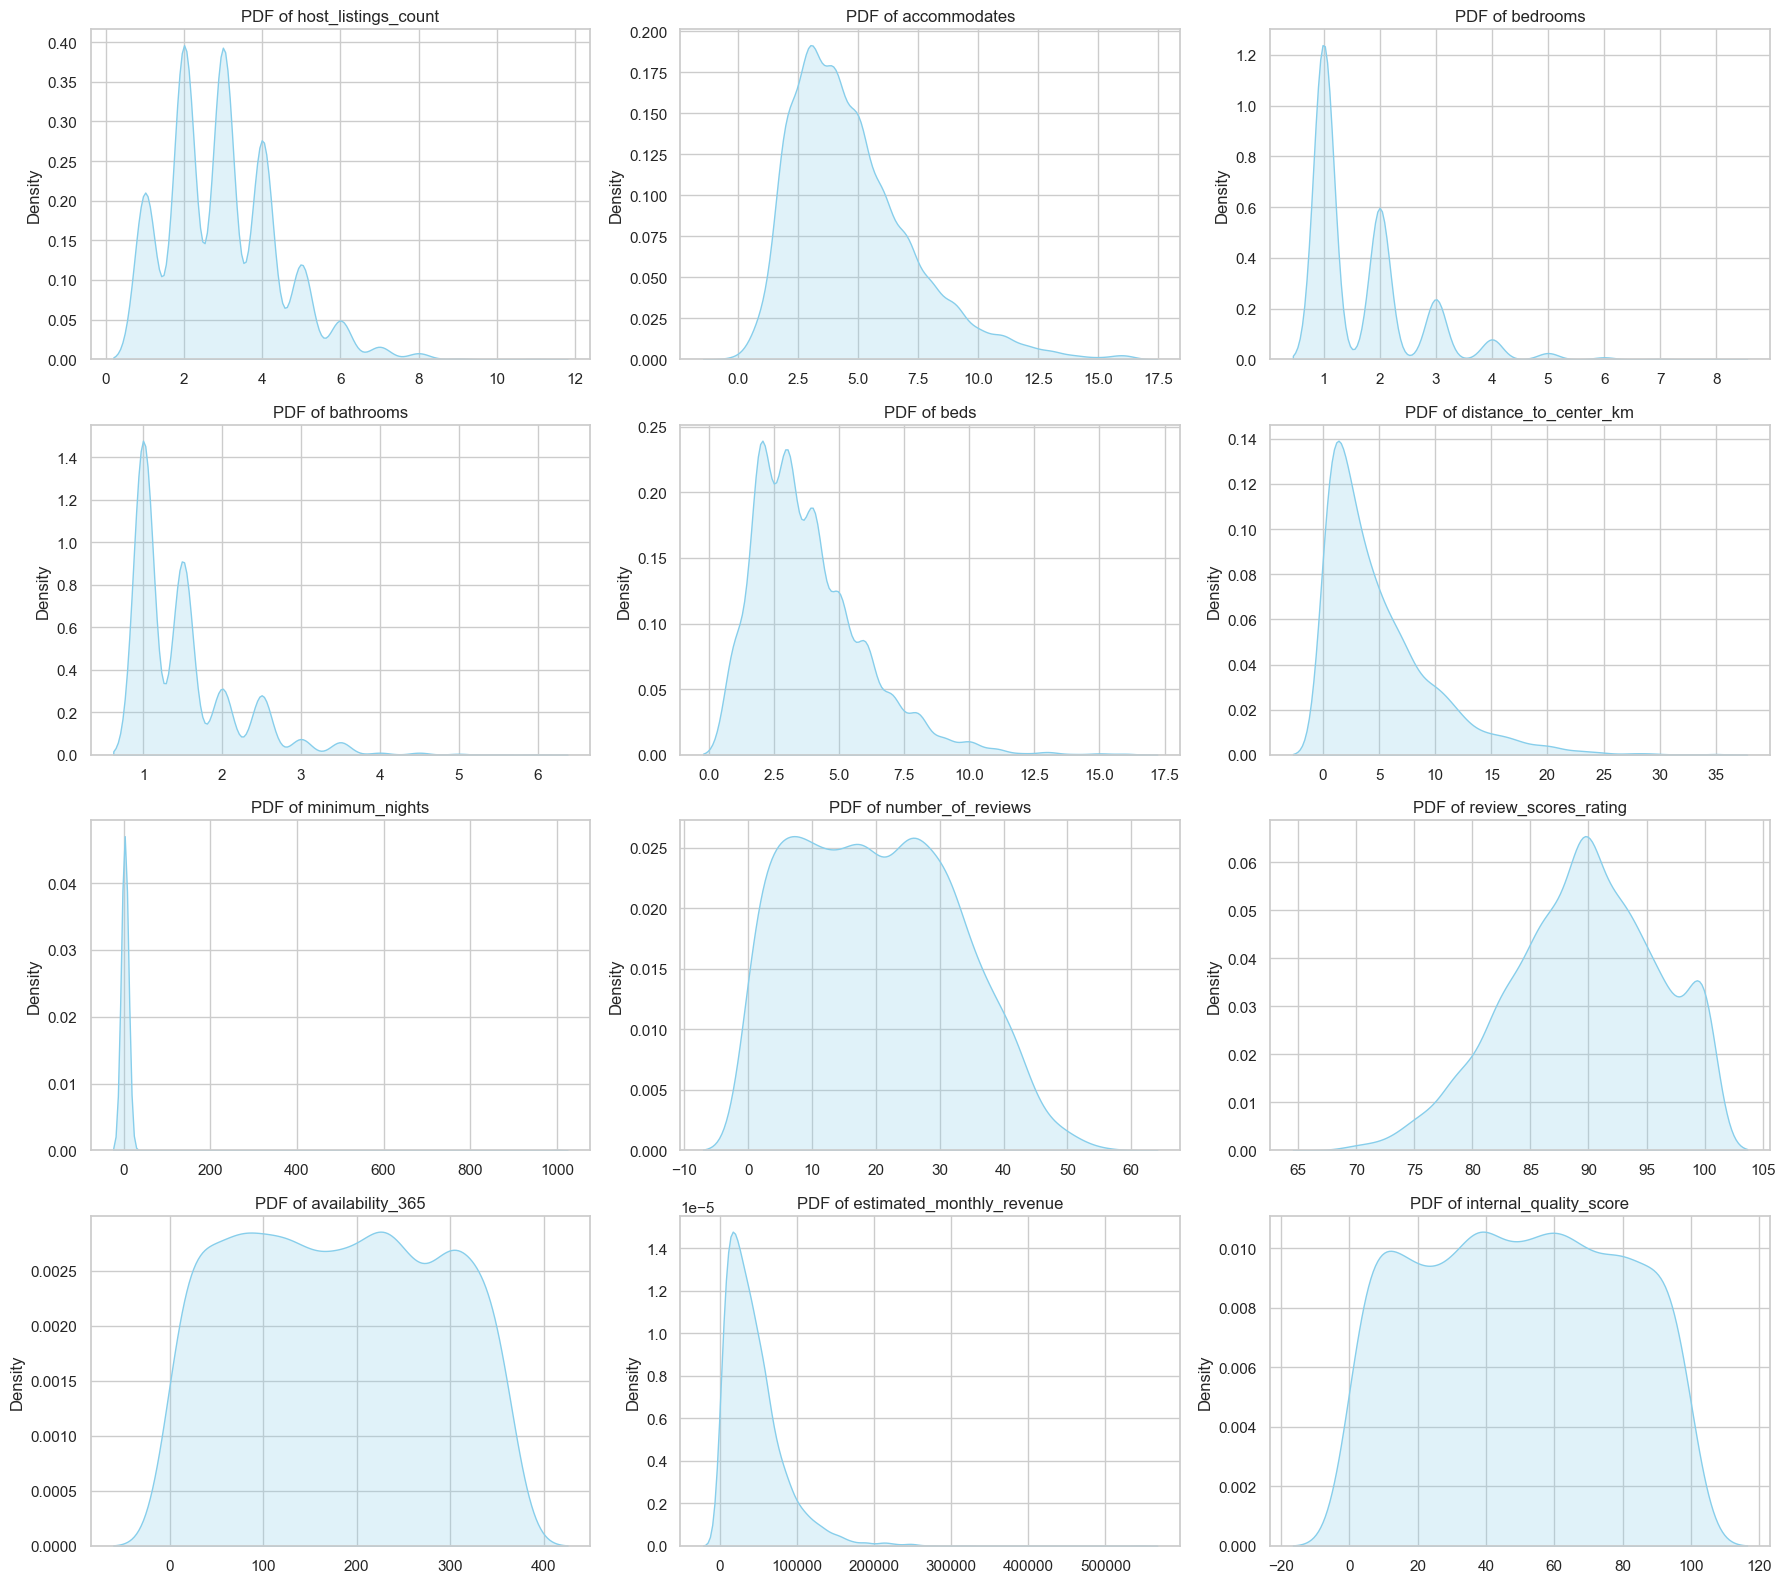

In [13]:
# Identify continuous columns (excluding IDs and categorical text)
continuous_cols = [
    'host_listings_count', 'accommodates', 'bedrooms', 'bathrooms', 'beds', 
    'distance_to_center_km', 'minimum_nights', 'number_of_reviews', 
    'review_scores_rating', 'availability_365', 'estimated_monthly_revenue', 
    'internal_quality_score'
]

# Set up the figure for subplots
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()  # Flatten the grid to make it easier to iterate

# Create a kdeplot for each column
for i, col in enumerate(continuous_cols):
    sns.kdeplot(data=df, x=col, ax=axes[i], fill=True, color='skyblue')
    axes[i].set_title(f'PDF of {col}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

### 7.1 Review scores distribution

A closer look at `review_scores_rating`, saved to file.

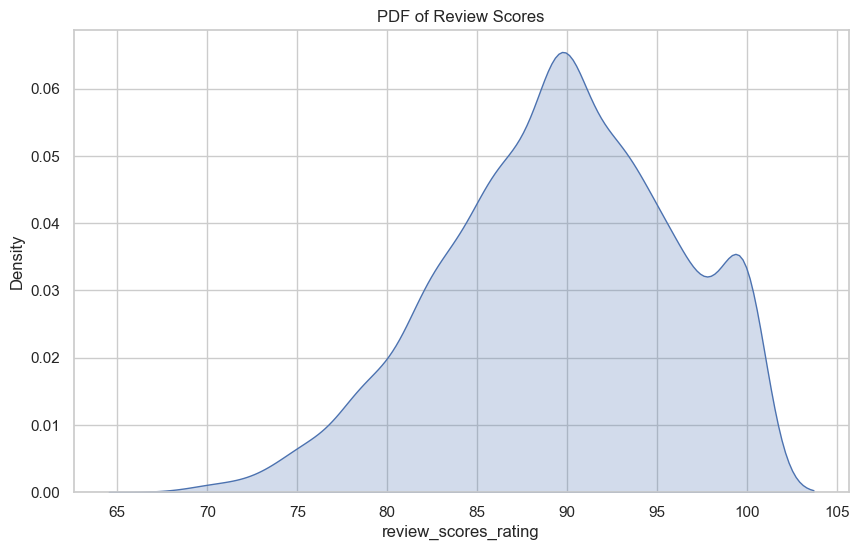

In [14]:
 # Create the plot
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='review_scores_rating', fill=True)
plt.title('PDF of Review Scores')

# Save the plot
plt.savefig('review_scores_pdf.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Clean the Price Column

`price` is stored as a string with a `₹` symbol and thousands separators (e.g. `₹4,647`). Strip those characters and convert to a numeric `float` so it can be used in plots and analysis.

In [15]:
# Clean price column: remove '₹' and ',' then convert to float
df['price'] = df['price'].replace({'\₹': '', ',': ''}, regex=True).astype(float)

### 8.1 Continuous variables vs Price

Scatter plots of each continuous variable against the cleaned `price`.

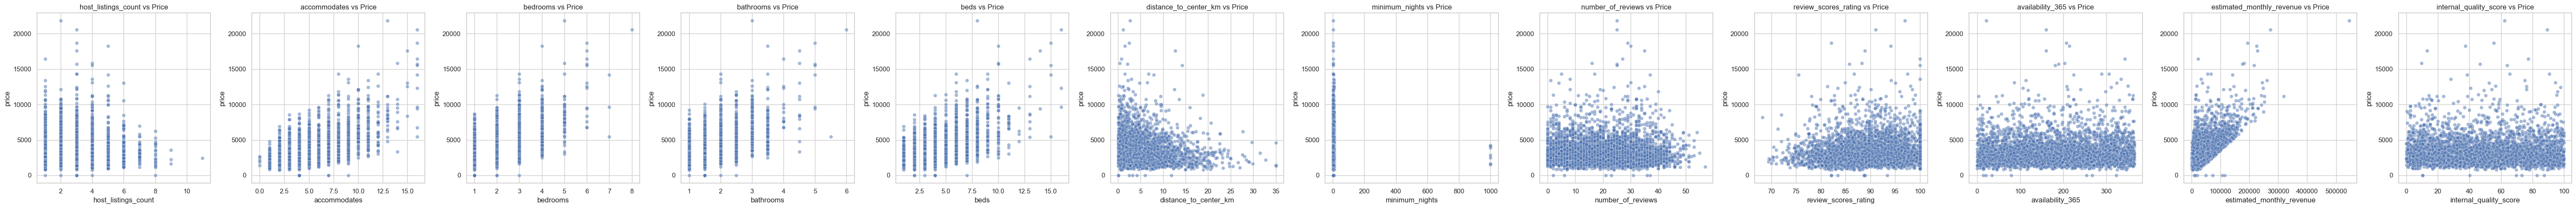

In [16]:
continuous_vars = [
    'host_listings_count', 'accommodates', 'bedrooms', 'bathrooms', 'beds', 
    'distance_to_center_km', 'minimum_nights', 'number_of_reviews', 
    'review_scores_rating', 'availability_365', 'estimated_monthly_revenue', 
    'internal_quality_score'
]

# Create subplots dynamically based on the number of variables
n = len(continuous_vars)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))

for i, col in enumerate(continuous_vars):
    sns.scatterplot(data=df, x=col, y='price', ax=axes[i], alpha=0.5)
    axes[i].set_title(f'{col} vs Price')

plt.tight_layout()
# Save the last figure to your current working directory
plt.savefig('my_scatter_plot.png', dpi=300, bbox_inches='tight')
plt.show()

### 8.2 Count plots of categorical variables

Counts and proportions for each categorical column, visualised together.


--- host_is_superhost Summary ---
                    Count Percentage
host_is_superhost                  
False               2704     70.84%
True                1113     29.16%

--- city Summary ---
            Count Percentage
city                       
Mumbai       891     23.34%
Delhi        808     21.17%
Bangalore    767     20.09%
Goa          527     13.81%
Pune         464     12.16%
Jaipur       360      9.43%

--- neighborhood Summary ---
                  Count Percentage
neighborhood                     
Powai              218      5.71%
Bandra             160      4.19%
Worli              148      3.88%
Colaba             147      3.85%
Connaught Place    143      3.75%
MG Road            142      3.72%
Saket              135      3.54%
Dwarka             134      3.51%
Karol Bagh         133      3.48%
HSR Layout         132      3.46%
Juhu               131      3.43%
Andheri            128      3.35%
Vasant Kunj        127      3.33%
Jayanagar          126      3.30

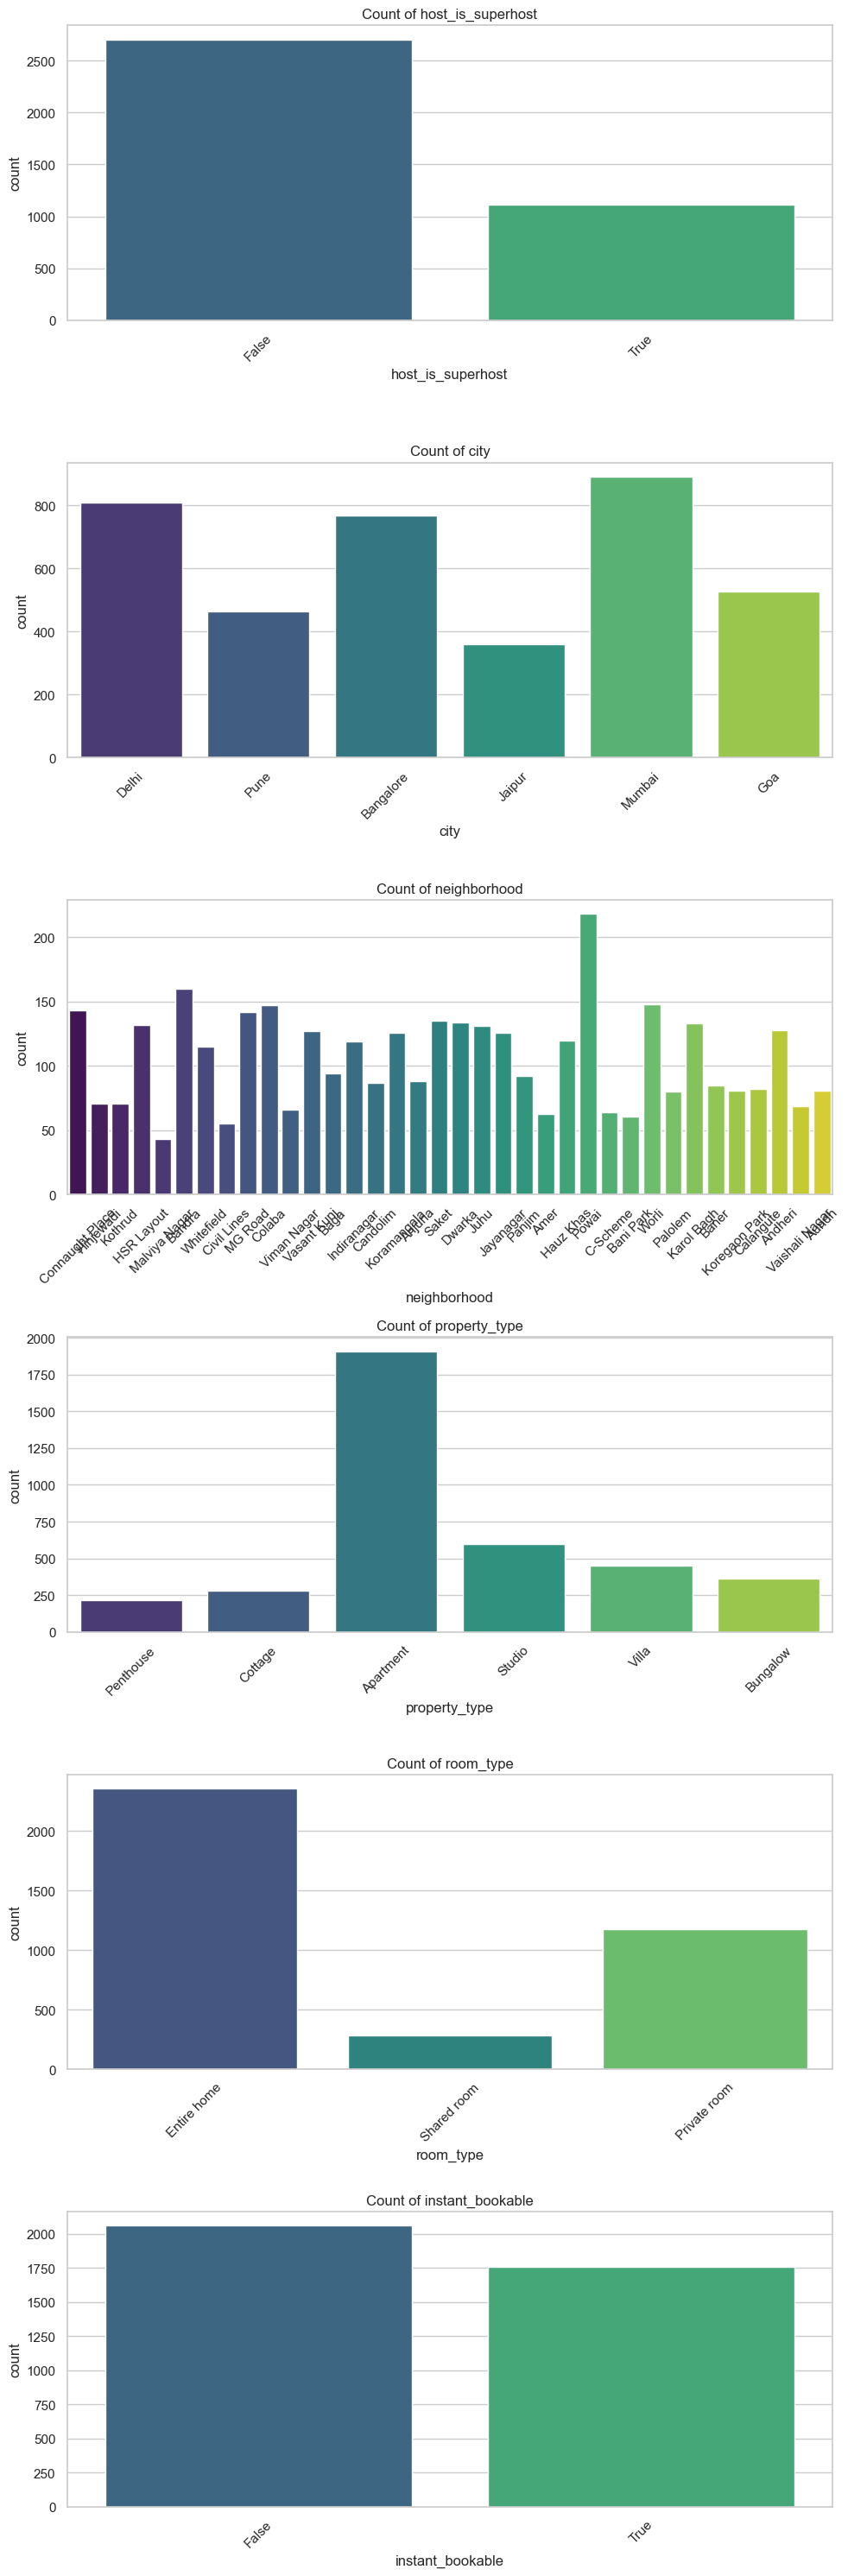

In [17]:
# 1. Define the categorical columns to analyze
cat_cols_to_analyze = ['host_is_superhost', 'city', 'neighborhood', 'property_type', 'room_type', 'instant_bookable']

# 2. Setup the Plotting Grid
# We calculate the number of rows/cols needed to keep the layout clean
n = len(cat_cols_to_analyze)
fig, axes = plt.subplots(n, 1, figsize=(10, 5 * n)) 

# If only one column, axes isn't a list, so we wrap it
if n == 1: axes = [axes]

# 3. Iterate and Plot
for i, col in enumerate(cat_cols_to_analyze):
    # Print numerical summary first
    counts = df[col].value_counts()
    percentages = df[col].value_counts(normalize=True) * 100
    summary = pd.DataFrame({'Count': counts, 'Percentage': percentages.map('{:.2f}%'.format)})
    print(f"\n--- {col} Summary ---\n", summary)
    
    # Plot using hue=col and legend=False to fix the warning
    sns.countplot(data=df, x=col, palette='viridis', hue=col, legend=False, ax=axes[i])
    axes[i].set_title(f'Count of {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
# Save the final combined plot
plt.savefig('categorical_counts_summary.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Cleaning the Categorical Variables

Standardise the boolean-style columns (`host_is_superhost`, `instant_bookable`) into true `True`/`False` values, and normalise the `city` text (trim whitespace, Title Case).

In [11]:
# ==========================================
# PART 1: CLEANING CATEGORICAL VARIABLES
# ==========================================

print("Starting categorical data cleaning...")

# 1. Clean 'host_is_superhost' and 'instant_bookable'
# Standardizing mixed boolean representations into standard Python booleans (True/False)
bool_mapping = {
    't': True, 'TRUE': True, 'True': True,
    'f': False, 'FALSE': False, 'False': False
}

df['host_is_superhost'] = df['host_is_superhost'].map(bool_mapping)
df['instant_bookable'] = df['instant_bookable'].map(bool_mapping)

# 2. Clean 'city'
# Removing leading/trailing whitespaces and standardizing to Title Case
df['city'] = df['city'].str.strip().str.title()

# ==========================================
# VERIFICATION
# ==========================================

print("\n--- Cleaned 'host_is_superhost' Summary ---")
print(df['host_is_superhost'].value_counts(dropna=False))

print("\n--- Cleaned 'instant_bookable' Summary ---")
print(df['instant_bookable'].value_counts(dropna=False))

print("\n--- Cleaned 'city' Summary ---")
print(df['city'].value_counts(dropna=False))

print("\nCategorical variables cleaned successfully.")

Starting categorical data cleaning...

--- Cleaned 'host_is_superhost' Summary ---
host_is_superhost
False    2679
True     1113
NaN        25
Name: count, dtype: int64

--- Cleaned 'instant_bookable' Summary ---
instant_bookable
False    2035
True     1758
NaN        24
Name: count, dtype: int64

--- Cleaned 'city' Summary ---
city
Mumbai       891
Delhi        808
Bangalore    767
Goa          527
Pune         464
Jaipur       360
Name: count, dtype: int64

Categorical variables cleaned successfully.


## 10. Handling Missing Values

Impute the remaining nulls: **median** for numeric columns (robust to outliers), **mode** for categorical/boolean columns, and the **median date** for `host_since`. A final check confirms no nulls remain.

In [12]:
# ==========================================
# PART 2: HANDLING MISSING VALUES (NULLS)
# ==========================================

print("Starting missing value imputation...")

# 1. Numeric Variables -> Replace with Median
# The median is perfect here because it is robust against outliers
numeric_null_cols = ['bedrooms', 'bathrooms', 'review_scores_rating']

for col in numeric_null_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"Filled {col} with median: {median_val}")

# 2. Categorical & Boolean Variables -> Replace with Mode
# We use the mode (most frequent value) for text and True/False data
categorical_null_cols = ['host_is_superhost', 'neighborhood', 'instant_bookable']

for col in categorical_null_cols:
    mode_val = df[col].mode()[0] # .mode() returns a Series, so we grab the first item [0]
    df[col] = df[col].fillna(mode_val)
    print(f"Filled {col} with mode: {mode_val}")

# 3. Datetime Variables -> Replace with Median Date
# Pandas allows us to calculate the median timestamp for dates
median_date = df['host_since'].median()
df['host_since'] = df['host_since'].fillna(median_date)
print(f"Filled host_since with median date: {median_date.date()}")

# ==========================================
# VERIFICATION
# ==========================================

print("\n--- Remaining Null Values Check ---")
# Check if any nulls are left across the entire DataFrame
print(df.isnull().sum()[df.isnull().sum() > 0]) 

print("\nMissing values handled successfully!")

Starting missing value imputation...
Filled bedrooms with median: 1.0
Filled bathrooms with median: 1.5
Filled review_scores_rating with median: 89.8
Filled host_is_superhost with mode: False
Filled neighborhood with mode: Powai
Filled instant_bookable with mode: False
Filled host_since with median date: 2019-12-04

--- Remaining Null Values Check ---
Series([], dtype: int64)

Missing values handled successfully!


C:\Users\saifa\AppData\Local\Temp\ipykernel_32520\3695657368.py:22: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(mode_val)


## ✅ DataFrame Ready

At this point the data types are corrected, invalid records are removed, the categorical variables are standardised, and all missing values are handled. The DataFrame `df` is clean and ready for the next steps. Continue your work in the cell below.

In [18]:


# List of categorical features to analyze against 'price'
categorical_vars =  ['host_is_superhost', 'city', 'neighborhood', 'property_type', 'room_type', 'instant_bookable']

# Analyze Price by Categorical Variables
for col in categorical_vars:
    # Group by the category and calculate mean and median for the price column
    summary = df.groupby(col)['price'].agg(['mean', 'median', 'count']).sort_values(by='median', ascending=False)
    
    print(f"\n--- Price Analysis by {col} ---")
    print(summary)
    print("-" * 40)



--- Price Analysis by host_is_superhost ---
                          mean  median  count
host_is_superhost                            
True               3587.306379  3112.0   1113
False              3363.938240  2881.5   2704
----------------------------------------

--- Price Analysis by city ---
                  mean  median  count
city                                 
Goa        4366.815939  3796.0    527
Mumbai     3867.626263  3327.0    891
Delhi      3243.602723  2828.5    808
Bangalore  3207.962190  2754.0    767
Jaipur     2849.538889  2470.5    360
Pune       2659.961207  2240.5    464
----------------------------------------

--- Price Analysis by neighborhood ---
                        mean  median  count
neighborhood                               
Baga             4738.659574  4364.5     94
Candolim         4282.551724  4021.0     87
Palolem          4363.987500  3889.0     80
Calangute        4421.439024  3663.5     82
Worli            4113.905405  3539.5    148
Panji

C:\Users\saifa\AppData\Local\Temp\ipykernel_32520\1960410935.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='price', ax=axes[i], palette='viridis')
C:\Users\saifa\AppData\Local\Temp\ipykernel_32520\1960410935.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='price', ax=axes[i], palette='viridis')
C:\Users\saifa\AppData\Local\Temp\ipykernel_32520\1960410935.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='price', ax=axes[i], palette='viridis')
C:\Users\saifa\AppData\Local\Te

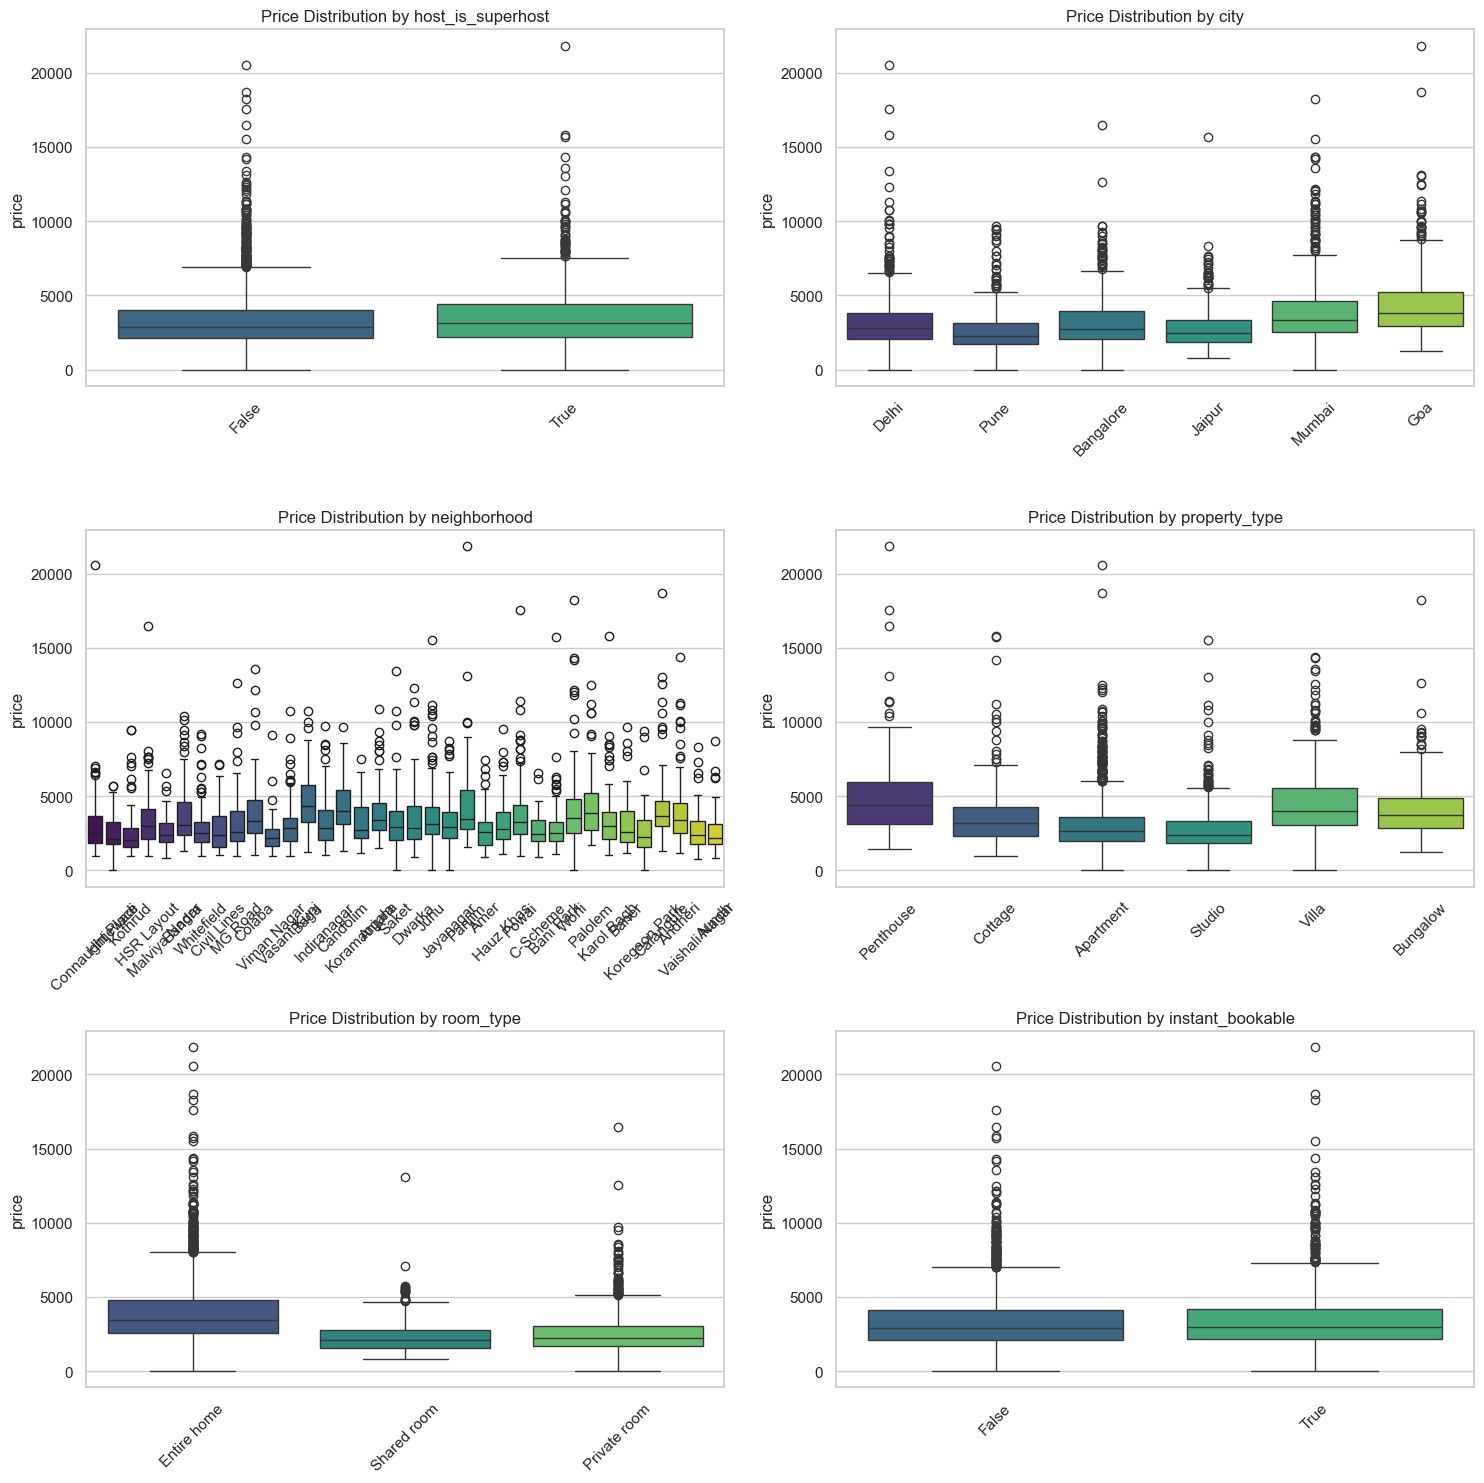

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the categorical variables
categorical_vars = ['host_is_superhost', 'city', 'neighborhood', 'property_type', 'room_type', 'instant_bookable']

# Set up the plot grid (we'll make a grid with 2 columns)
# Adjust the number of rows based on the number of variables
n_cols = 2
n_rows = (len(categorical_vars) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()  # Flatten to make it easier to iterate

# Iterate through variables and create a boxplot for each
for i, col in enumerate(categorical_vars):
    sns.boxplot(data=df, x=col, y='price', ax=axes[i], palette='viridis')
    axes[i].set_title(f'Price Distribution by {col}')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')

# Remove empty subplots if the number of variables is odd
if len(categorical_vars) % 2 != 0:
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.savefig('categorical_price_analysis.png', dpi=300)
plt.show()

In [20]:
print(df[['price', 'estimated_monthly_revenue', 'internal_quality_score']].corr())

                              price  estimated_monthly_revenue  \
price                      1.000000                   0.634982   
estimated_monthly_revenue  0.634982                   1.000000   
internal_quality_score    -0.003973                  -0.008466   

                           internal_quality_score  
price                                   -0.003973  
estimated_monthly_revenue               -0.008466  
internal_quality_score                   1.000000  


In [21]:
# ============================================================
# FEATURE ENGINEERING
# Works on a copy so the cleaned `df` stays intact.
# ============================================================
import numpy as np

fe = df.copy()
REFERENCE_DATE = fe['host_since'].max()   # reproducible anchor, not "today"

# ===== 1 · HOST =====
fe['host_tenure_days']         = (REFERENCE_DATE - fe['host_since']).dt.days
fe['host_tenure_years']        = fe['host_tenure_days'] / 365.25
fe['listings_per_tenure_year'] = fe['host_listings_count'] / (fe['host_tenure_years'] + 1)
fe['is_superhost']             = fe['host_is_superhost'].astype(int)

# ===== 2 · GEOGRAPHY =====
print('Unique cities:', fe['city'].nunique(), '| neighborhoods:', fe['neighborhood'].nunique())

# Route 1: describe each neighborhood by its OTHER attributes (no price -> no leakage)
nbhd_agg = fe.groupby('neighborhood').agg(
    nbhd_avg_distance     = ('distance_to_center_km', 'mean'),
    nbhd_avg_accommodates = ('accommodates', 'mean'),
    nbhd_avg_rating       = ('review_scores_rating', 'mean'),
    nbhd_superhost_rate   = ('host_is_superhost', 'mean'),
    nbhd_entire_home_rate = ('room_type', lambda s: (s == 'Entire home').mean()),
)
fe = fe.merge(nbhd_agg, on='neighborhood', how='left')

# Distance features (your inverse trend, made model-friendly)
fe['is_central_1km']       = (fe['distance_to_center_km'] < 1).astype(int)
fe['is_central_2km']       = (fe['distance_to_center_km'] < 2).astype(int)
fe['distance_vs_city_avg'] = fe['distance_to_center_km'] - fe.groupby('city')['distance_to_center_km'].transform('mean')

# ===== 3 · PROPERTY =====
fe['bed_bath_ratio']     = fe['bedrooms']     / fe['bathrooms'].replace(0, np.nan)
fe['bath_per_guest']     = fe['bathrooms']    / fe['accommodates'].replace(0, np.nan)
fe['beds_per_guest']     = fe['beds']         / fe['accommodates'].replace(0, np.nan)
fe['guests_per_bedroom'] = fe['accommodates'] / fe['bedrooms'].replace(0, np.nan)

ratio_cols = ['bed_bath_ratio', 'bath_per_guest', 'beds_per_guest', 'guests_per_bedroom']
fe[ratio_cols] = fe[ratio_cols].fillna(fe[ratio_cols].median())

fe['is_large_property'] = (fe['accommodates'] >= 4).astype(int)

# Inspect the property/room relationship, then encode the combo (kept per your "rest looks good")
print(pd.crosstab(fe['property_type'], fe['room_type']))
fe['prop_room_combo'] = fe['property_type'] + ' | ' + fe['room_type']
fe['prop_room_freq']  = fe['prop_room_combo'].map(fe['prop_room_combo'].value_counts(normalize=True))

# ===== 4 · RATINGS =====
fe['has_reviews']             = (fe['number_of_reviews'] > 0).astype(int)
fe['log_reviews']             = np.log1p(fe['number_of_reviews'])   # reviews are heavily skewed
fe['reviews_per_tenure_year'] = fe['number_of_reviews'] / (fe['host_tenure_years'] + 1)

# ===== 5 · PERKS (amenities + booking) =====
fe['amenities_list'] = (
    fe['amenities'].str.strip('{}').str.split(',')
      .apply(lambda lst: [a.strip() for a in lst if a.strip()])
)
fe['amenity_count'] = fe['amenities_list'].apply(len)

key_amenities = ['Wifi', 'AC', 'Pool', 'Kitchen', 'Parking', 'TV',
                 'Heater', 'Washing Machine', 'Workspace', 'Pet Friendly']
for a in key_amenities:
    fe['has_' + a.lower().replace(' ', '_')] = fe['amenities_list'].apply(lambda lst, a=a: int(a in lst))

fe['is_instant_bookable'] = fe['instant_bookable'].astype(int)
fe['availability_ratio']  = fe['availability_365'] / 365

# ===== 6 · REVENUE (EDA only — NOT a model feature) =====
# Revenue is a downstream outcome (you earn it after pricing), so it leaks. Kept only for segmentation.
bins   = [0, 1e5, 2e5, 3e5, 4e5, 5e5, 6e5, 7e5, 8e5, 9e5, 10e5]
labels = ['0-1L','1-2L','2-3L','3-4L','4-5L','5-6L','6-7L','7-8L','8-9L','9-10L']
fe['revenue_band'] = pd.cut(fe['estimated_monthly_revenue'], bins=bins, labels=labels, include_lowest=True)

# ===== 7 · ENCODE LOW-CARDINALITY CATEGORICALS =====
fe = pd.get_dummies(fe, columns=['city', 'room_type', 'property_type'],
                    prefix=['city', 'room', 'prop'], drop_first=False)
# Use drop_first=True for a linear model (avoids the dummy trap); keep False for trees.

# ===== 8 · BUILD THE FINAL MODELING FRAME =====
drop_cols = [
    'listing_id', 'host_id', 'host_since',          # identifiers / raw date
    'host_is_superhost', 'instant_bookable',        # replaced by int flags
    'neighborhood', 'amenities', 'amenities_list',  # replaced by aggregates / parsed
    'prop_room_combo',                              # helper text
    'estimated_monthly_revenue', 'revenue_band',    # leaky (downstream of price)
]
model_df = fe.drop(columns=[c for c in drop_cols if c in fe.columns])

# Make boolean dummy columns plain 0/1 ints (safer across model types)
bool_cols = model_df.select_dtypes(include='bool').columns
model_df[bool_cols] = model_df[bool_cols].astype(int)

print('Final modeling frame shape:', model_df.shape)
print('Remaining nulls:', model_df.isnull().sum().sum())
model_df.head()

Unique cities: 6 | neighborhoods: 36
room_type      Entire home  Private room  Shared room
property_type                                        
Apartment             1174           594          140
Bungalow               214           116           31
Cottage                184            80           17
Penthouse              135            61           20
Studio                 373           181           45
Villa                  275           143           34
Final modeling frame shape: (3817, 61)
Remaining nulls: 0


,host_listings_count,accommodates,bedrooms,bathrooms,beds,distance_to_center_km,minimum_nights,number_of_reviews,review_scores_rating,availability_365,...,city_Pune,room_Entire home,room_Private room,room_Shared room,prop_Apartment,prop_Bungalow,prop_Cottage,prop_Penthouse,prop_Studio,prop_Villa
0,1,6,2.0,1.5,4,0.19,1,23,82.5,197,...,0,1,0,0,0,0,0,1,0,0
1,4,7,3.0,2.5,6,3.52,1,5,90.0,141,...,1,0,0,1,0,0,1,0,0,0
2,3,5,1.0,1.5,3,10.40,7,13,91.5,48,...,1,0,1,0,1,0,0,0,0,0
3,2,2,1.0,1.0,2,4.86,3,16,83.0,150,...,0,0,0,1,0,0,0,0,1,0
4,3,2,1.0,1.0,2,2.99,7,16,74.2,111,...,0,1,0,0,0,0,0,0,0,1


In [23]:
# Print as a list
print(list(model_df.columns))

['host_listings_count', 'accommodates', 'bedrooms', 'bathrooms', 'beds', 'distance_to_center_km', 'minimum_nights', 'number_of_reviews', 'review_scores_rating', 'availability_365', 'internal_quality_score', 'price', 'host_tenure_days', 'host_tenure_years', 'listings_per_tenure_year', 'is_superhost', 'nbhd_avg_distance', 'nbhd_avg_accommodates', 'nbhd_avg_rating', 'nbhd_superhost_rate', 'nbhd_entire_home_rate', 'is_central_1km', 'is_central_2km', 'distance_vs_city_avg', 'bed_bath_ratio', 'bath_per_guest', 'beds_per_guest', 'guests_per_bedroom', 'is_large_property', 'prop_room_freq', 'has_reviews', 'log_reviews', 'reviews_per_tenure_year', 'amenity_count', 'has_wifi', 'has_ac', 'has_pool', 'has_kitchen', 'has_parking', 'has_tv', 'has_heater', 'has_washing_machine', 'has_workspace', 'has_pet_friendly', 'is_instant_bookable', 'availability_ratio', 'city_Bangalore', 'city_Delhi', 'city_Goa', 'city_Jaipur', 'city_Mumbai', 'city_Pune', 'room_Entire home', 'room_Private room', 'room_Shared roo